In [ ]:
LANGUAGE = "en"

In [2]:
from numpy import linspace
from numpy import exp, log, cosh, maximum, tanh

In [3]:
from matplotlib import rcParams 
from matplotlib.pyplot import subplots 
from matplotlib.pyplot import show, close
from matplotlib import cm
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
 
rcParams.update({
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "axes.linewidth": 1.1,
})

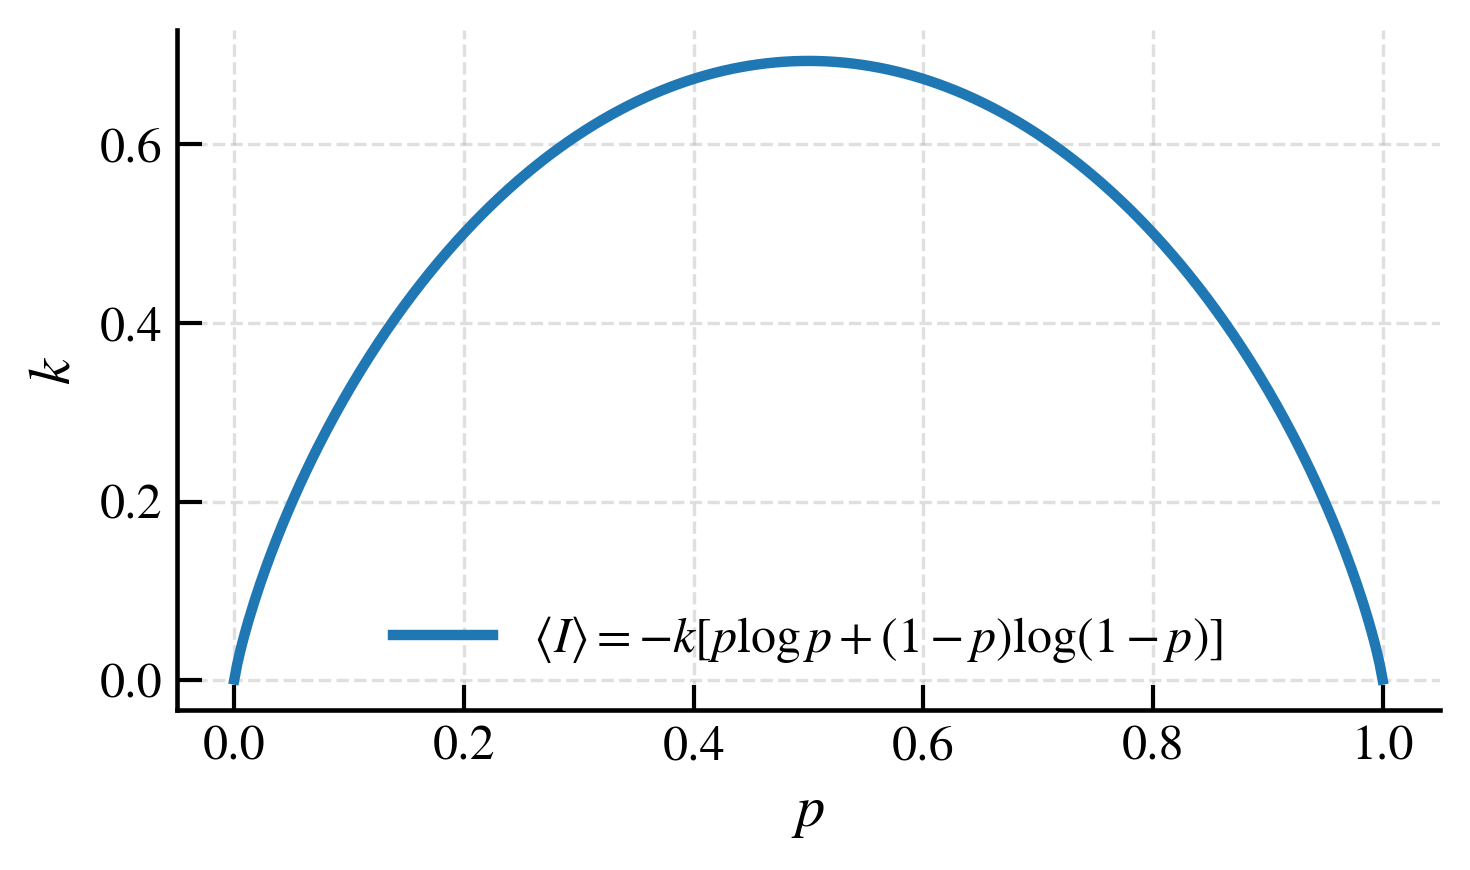

In [4]:
TEXT = {
    "en": {
        "xlabel": r"$p$",
        "ylabel": r"$k$",
        "title": "Information",
        "filename": "entropy_plot_en.pdf",
    },
    "es": {
        "xlabel": r"$p$",
        "ylabel": r"$k$",
        "title": "Información",
        "filename": "entropy_plot_es.pdf",
    },
}
 
text = TEXT[LANGUAGE]

k = 1.0
probability = linspace(1e-4, 1 - 1e-4, 400)

entropy = -k * (
    probability * log(probability)
    + (1 - probability) * log(1 - probability)
)

figure, axes = subplots(figsize=(5, 3), dpi=300)

axes.plot(
    probability,
    entropy,
    linewidth=2.5,
    label=r"$\langle I \rangle = -k[p\log p + (1-p)\log(1-p)]$",
)

axes.set_xlabel(text["xlabel"])
axes.set_ylabel(text["ylabel"])
#axes.set_title(text["title"])

axes.grid(True, linestyle="--", alpha=0.4)
axes.tick_params(direction="in", length=6, width=1)

axes.spines["top"].set_visible(False)
axes.spines["right"].set_visible(False)

axes.legend(frameon=False)

figure.tight_layout()
figure.savefig(text["filename"], dpi=300)
 
show(figure)
close(figure)

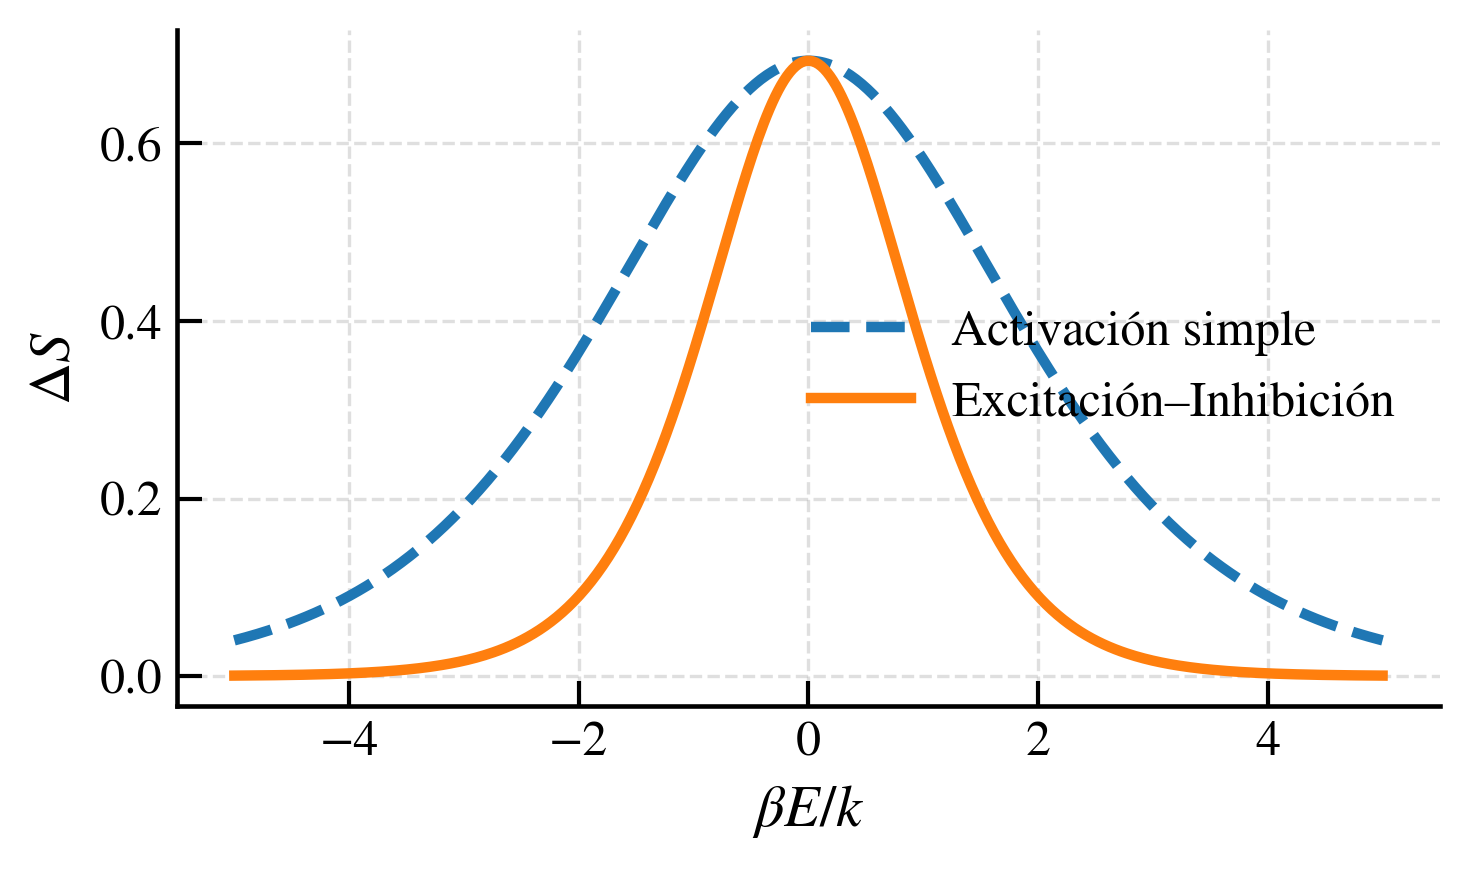

In [5]:
TEXT = {
    "en": {
        "title": "Entropy production",
        "xlabel": r"$\beta E / k$",
        "ylabel": r"$\Delta S$",
        "label_sigmoid": "Simple activation",
        "label_two": "Excitation–Inhibition",
        "filename": "entropy_comparison_en.pdf",
    },
    "es": {
        "title": "Producción de entropía",
        "xlabel": r"$\beta E / k$",
        "ylabel": r"$\Delta S$",
        "label_sigmoid": "Activación simple",
        "label_two": "Excitación–Inhibición",
        "filename": "entropy_comparison_es.pdf",
    },
}

text = TEXT[LANGUAGE]


k = 1.0
y = linspace(-5.0, 5.0, 400)

p = 1.0 / (1.0 + exp(-y))
H_sig = -k * (p * log(p) + (1.0 - p) * log(1.0 - p))

p_plus = exp(y) / (2.0 * cosh(y))
p_minus = exp(-y) / (2.0 * cosh(y))
H_two = -k * (p_plus * log(p_plus) + p_minus * log(p_minus))


figure, axes = subplots(figsize=(5, 3), dpi=300)

axes.plot(
    y,
    H_sig,
    linewidth=2.5,
    linestyle="--",
    label=text["label_sigmoid"]
)

axes.plot(
    y,
    H_two,
    linewidth=2.5,
    label=text["label_two"]
)

axes.set_xlabel(text["xlabel"])
axes.set_ylabel(text["ylabel"])
#axes.set_title(text["title"])

axes.grid(True, linestyle="--", alpha=0.4)
axes.tick_params(direction="in", length=6, width=1)

axes.spines["top"].set_visible(False)
axes.spines["right"].set_visible(False)

axes.legend(frameon=False)

figure.tight_layout()
figure.savefig(text["filename"], dpi=300)
show(figure)
close(figure)
